# Data and libraries

In [683]:
# standard packaging

import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(color_codes=True, rc={'figure.figsize':(10,8)})

from IPython.display import HTML #Youtube embed

In [684]:
# load the dataset from GitHub - original source

data = pd.read_csv("data/bcn_noise_class_ml_dataset.csv")

# Data Inspection

In [685]:
#inspect data
data.info()
data['width_x_betw'] = data['width'] * data['betw_centrality']
data['min_arterial_dist'] = data[['dist_to_trunk', 'dist_to_primary', 'dist_to_secondary']].min(axis=1)
data['min_local_road_dist'] = data[['dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street']].min(axis=1)
print(data)

<class 'pandas.DataFrame'>
RangeIndex: 11711 entries, 0 to 11710
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                11711 non-null  str    
 1   noise_day              11711 non-null  int64  
 2   noise_evening          11711 non-null  int64  
 3   noise_night            11711 non-null  int64  
 4   road_category          11711 non-null  int64  
 5   dist_to_trunk          11711 non-null  float64
 6   dist_to_primary        11711 non-null  float64
 7   dist_to_secondary      11711 non-null  float64
 8   dist_to_tertiary       11711 non-null  float64
 9   dist_to_residential    11711 non-null  float64
 10  dist_to_living_street  11711 non-null  float64
 11  signals                11711 non-null  float64
 12  transport              11711 non-null  float64
 13  pois                   11711 non-null  float64
 14  width                  11711 non-null  float64
 15  height       

In [686]:
print(data)

                         road_id  noise_day  noise_evening  noise_night  \
0            21638868_30343649_0          2              2            1   
1            21638865_30343650_0          1              1            0   
2      13859746868_13859746870_0          3              2            2   
3           21638917_190981834_0          4              4            3   
4           21638891_190971702_0          3              3            3   
...                          ...        ...            ...          ...   
11706    2239783361_4577282718_0          3              3            2   
11707     2239783361_885307899_0          3              3            2   
11708     885307964_4577282718_0          3              3            2   
11709      885307964_885307899_0          3              3            2   
11710      885307899_885307964_0          3              3            2   

       road_category  dist_to_trunk  dist_to_primary  dist_to_secondary  \
0                  4    

In [687]:
data_clean = data.dropna(how = "any")
data_clean.info()
data_clean.reset_index(inplace=True, drop = True)
data_clean

<class 'pandas.DataFrame'>
RangeIndex: 11711 entries, 0 to 11710
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                11711 non-null  str    
 1   noise_day              11711 non-null  int64  
 2   noise_evening          11711 non-null  int64  
 3   noise_night            11711 non-null  int64  
 4   road_category          11711 non-null  int64  
 5   dist_to_trunk          11711 non-null  float64
 6   dist_to_primary        11711 non-null  float64
 7   dist_to_secondary      11711 non-null  float64
 8   dist_to_tertiary       11711 non-null  float64
 9   dist_to_residential    11711 non-null  float64
 10  dist_to_living_street  11711 non-null  float64
 11  signals                11711 non-null  float64
 12  transport              11711 non-null  float64
 13  pois                   11711 non-null  float64
 14  width                  11711 non-null  float64
 15  height       

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,...,width,height,betw_centrality,clos_centrality,green_100,straightness,closeness400,width_x_betw,min_arterial_dist,min_local_road_dist
0,21638868_30343649_0,2,2,1,4,1462.932115,2131.092865,492.904878,0.000000,0.000000,...,36.850912,9.0,1.814443e-03,0.000167,0.000000,0.828127,0.000051,0.066864,492.904878,0.000000
1,21638865_30343650_0,1,1,0,6,1420.227896,2300.048237,675.721286,192.974974,0.000000,...,28.095584,12.0,2.241147e-04,0.000161,0.000000,0.822206,0.000031,0.006297,675.721286,0.000000
2,13859746868_13859746870_0,3,2,2,5,232.687902,502.124710,1111.341716,188.971039,0.000000,...,43.582332,30.0,5.400053e-04,0.000186,6.989905,0.807988,0.000017,0.023535,232.687902,0.000000
3,21638917_190981834_0,4,4,3,3,588.464995,1609.386075,0.000000,58.492257,162.714827,...,0.000000,0.0,1.973405e-04,0.000183,0.000000,0.869039,0.000019,0.000000,0.000000,48.558225
4,21638891_190971702_0,3,3,3,4,1432.029299,1409.121451,149.242081,0.000000,151.351124,...,50.000000,0.0,2.128625e-04,0.000189,0.000000,0.849742,0.000018,0.010643,149.242081,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11706,2239783361_4577282718_0,3,3,2,5,1071.169850,2765.104178,1043.493855,623.734708,0.000000,...,0.000000,0.0,2.511652e-08,0.000144,13.060793,0.794892,0.000009,0.000000,1043.493855,0.000000
11707,2239783361_885307899_0,3,3,2,5,1071.169850,2765.104178,1043.493855,537.238024,0.000000,...,0.000000,0.0,2.240896e-04,0.000142,10.096405,0.793172,0.000007,0.000000,1043.493855,0.000000
11708,885307964_4577282718_0,3,3,2,5,1094.565820,2783.460093,1065.046236,551.681619,0.000000,...,0.000000,0.0,2.240896e-04,0.000142,12.038550,0.794023,0.000007,0.000000,1065.046236,0.000000
11709,885307964_885307899_0,3,3,2,5,1091.813330,2832.850856,1092.735349,537.238024,0.000000,...,0.000000,0.0,7.534957e-08,0.000141,7.167431,0.792303,0.000005,0.000000,1091.813330,0.000000


### scaling

In [688]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [689]:
X = data_clean.drop(columns=['road_id','noise_day','noise_evening', 'noise_night','height','width','road_category','betw_centrality']) 
X_scaled = scaler.fit_transform(X)
X.head()

,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street,signals,transport,pois,clos_centrality,green_100,straightness,closeness400,width_x_betw,min_arterial_dist,min_local_road_dist
0,1462.932115,2131.092865,492.904878,0.000000,0.000000,0.000000,6.639758,19.919274,99.596371,0.000167,0.000000,0.828127,0.000051,0.066864,492.904878,0.000000
1,1420.227896,2300.048237,675.721286,192.974974,0.000000,0.000000,6.465793,12.931587,100.000000,0.000161,0.000000,0.822206,0.000031,0.006297,675.721286,0.000000
2,232.687902,502.124710,1111.341716,188.971039,0.000000,385.612798,13.030508,26.061017,26.061017,0.000186,6.989905,0.807988,0.000017,0.023535,232.687902,0.000000
3,588.464995,1609.386075,0.000000,58.492257,162.714827,48.558225,32.577907,19.546744,6.515581,0.000183,0.000000,0.869039,0.000019,0.000000,0.000000,48.558225
4,1432.029299,1409.121451,149.242081,0.000000,151.351124,184.454492,26.107982,20.886386,83.545543,0.000189,0.000000,0.849742,0.000018,0.010643,149.242081,0.000000


In [690]:
import numpy as np
y = np.asarray(data_clean["noise_day"])
y

array([2, 1, 3, ..., 3, 3, 3], shape=(11711,))

### splitting

In [691]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, data_train, data_test = train_test_split(X_scaled, y, data, test_size = 0.2, random_state = 42)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)


(9368, 16)
(9368,)
(2343, 16)


# Train model

In [692]:
# Import K-fold crossvalidation
from sklearn.model_selection import cross_val_score

# Import Classification Report for later evaluatoion of performance
from sklearn.metrics import classification_report

## Logistic Regression

In [693]:
# Import and instantiate the model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=2000)

# K-fold cross-validation (splitting the 80% into 5 chunks, using 4 to train and 1 to evaluate)
scores = cross_val_score(model, X_train, y_train, cv = 5)
print(scores)



[0.57577375 0.5773746  0.58164354 0.58142018 0.56433529]


In [694]:
# Model training
model.fit(X_train, y_train)

# Model performance on the test-set
print(model.score(X_test, y_test))

0.5842936406316688


In [695]:
y_pred = model.predict(X_test)


(<Figure size 1000x800 with 2 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

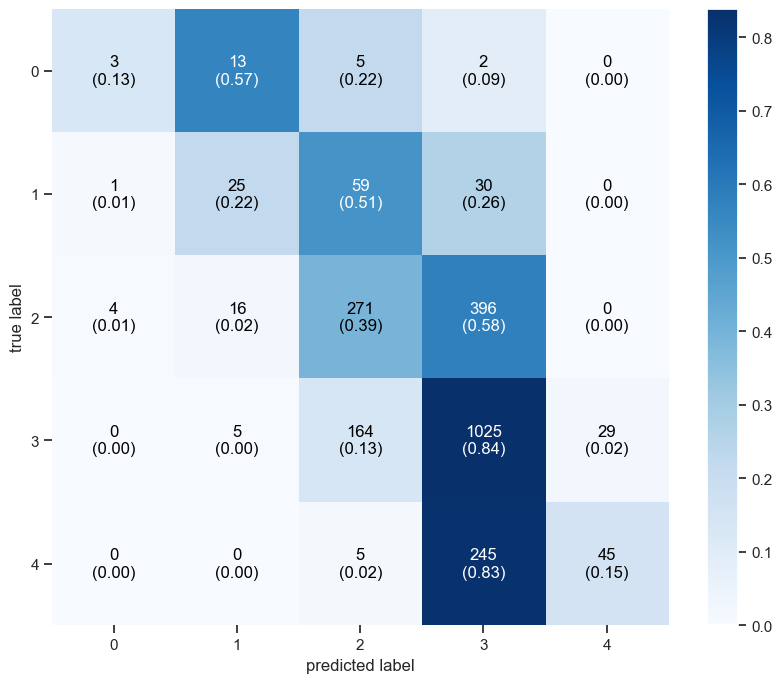

In [696]:
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix

confmatrix = confusion_matrix(y_test,y_pred)
plot_confusion_matrix(conf_mat=confmatrix,colorbar=True,show_absolute=True,show_normed=True,hide_spines = True)

## XG boost

In [697]:
import xgboost as xgb

model = xgb.XGBClassifier(
    )

scores = cross_val_score(model, X_train, y_train, cv = 5)
print(scores)

model.fit(X_train, y_train)
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

[0.69743863 0.69743863 0.70170758 0.70688735 0.70154832]
0.9708582408198121
0.7200170721297482


In [698]:
# Performance evaluation using the classification_report
y_pred = model.predict(X_test) # predict from the testset


In [699]:
data_test["y_pred"]= y_pred
data_test["y_truth"]= y_test
data_test["y_diff"]= y_pred - y_test

(<Figure size 1000x800 with 2 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

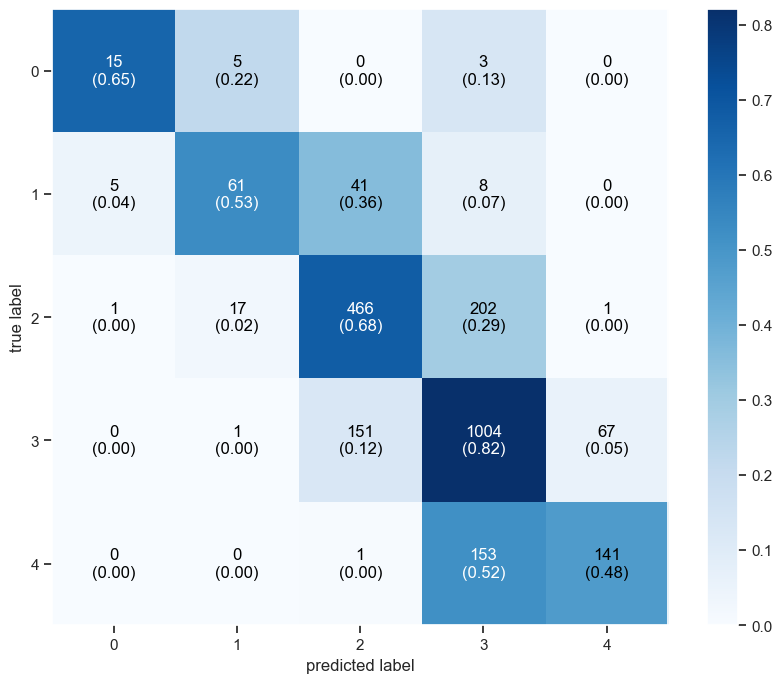

In [700]:
# calculate the confusion matrix
confmatrix = confusion_matrix(y_test,y_pred)

# Let's plot
plot_confusion_matrix(conf_mat=confmatrix,
                                colorbar=True,
                                show_absolute=True,
                                show_normed=True)

In [701]:
osm_roads = gpd.read_file("data/bcn_osmnx_edges.gpkg")
merged_gdf = osm_roads.merge(data_test, left_on='segment_id', right_on='road_id', how='left')

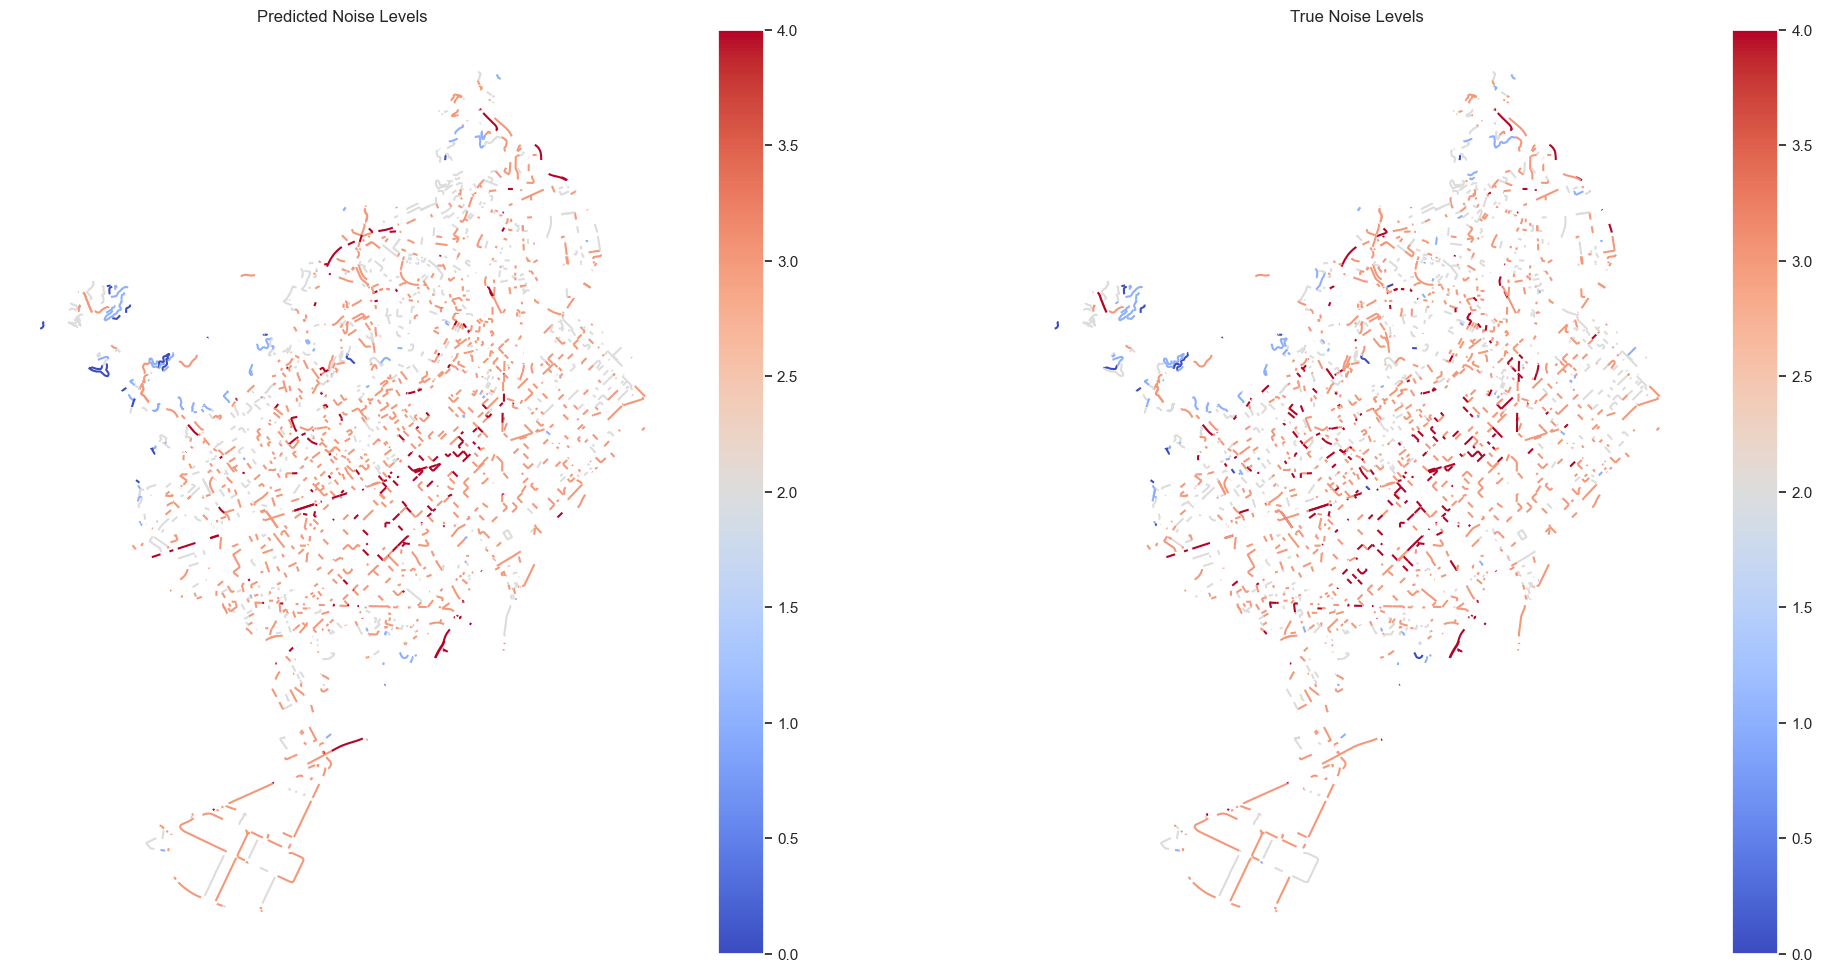

In [702]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

merged_gdf.plot(
    column='y_pred', 
    cmap='coolwarm', 
    legend=True, 
    ax=axes[0]
)
axes[0].set_title("Predicted Noise Levels")
axes[0].set_axis_off()

merged_gdf.plot(
    column='y_truth', 
    cmap='coolwarm', 
    legend=True, 
    ax=axes[1]
)
axes[1].set_title("True Noise Levels")
axes[1].set_axis_off()


## Random Forest

In [703]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test).round()


In [704]:
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.9435780431729972
0.6120219513574174
